# Fixation mRNN Single-Model Properties

This notebook inspects one selected condition-only Elman mRNN fit in detail.

Selected default fit:

- Target mode: 42 region PCs
- Input: 3 fixation-condition one-hot channels, no temporal Gaussian channels
- Loss setting: `pc_plus_fr`
- Hidden units per region: 50
- Learning rate: `1e-3`
- Training iterations: 25,000

The notebook defaults to loading an existing saved checkpoint. For the first run, if the checkpoint is absent, set `run_mode = "train"` in Section 2 and rerun the load/train cell.

## 1. Setup

In [1]:
from pathlib import Path
from dataclasses import replace
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from dal_monte_2022_analysis.ephys.modeling import (
    backproject_replay_outputs_to_firing_rates,
    extract_region_currents,
    load_fixation_mrnn_config,
    make_targets,
    pc_reconstructed_firing_rate_accuracy,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    resolve_fixation_mrnn_output_root,
    settings_from_config,
    train_fixation_mrnn_scratch,
    variance_comparison,
)
from dal_monte_2022_analysis.ephys.plotting import (
    FixationMRNNDiagnosticPlotSettings,
    plot_fixation_mrnn_average_current_influence_bars,
    plot_fixation_mrnn_current_influence,
    plot_fixation_mrnn_signal_evolution,
)


def display_figure(fig, *, dpi=95):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


CONDITION_COLORS = {
    "face_interactive": "#b64198",
    "face_non_interactive": "#4c9a2a",
    "object": "#6f4e37",
}


## 2. Model Choice and Load/Train Mode

Default behavior is `run_mode = "load"`, which rebuilds the scratch ID and loads the saved checkpoint. This lets you remake all analysis plots without refitting. If no saved checkpoint exists yet, change `run_mode` to `"train"` for the first execution.

In [2]:
cfg = load_fixation_mrnn_config(repo_root / "configs" / "ephys_fixation_mrnn.yaml")
base_settings = settings_from_config(cfg)
base_settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
base_settings.device = "auto"
base_settings.target_mode = "region_pcs"
base_settings.temporal_basis_count = 0
base_settings.epochs = 25_000
base_settings.activation = "softplus"
base_settings.spectral_radius = 1.0
base_settings.l1_weight_scale = 0.0
base_settings.l1_rate_scale = 0.0
base_settings.l2_weight_scale = 0.0
base_settings.l2_rate_scale = 0.0
base_settings.gradient_clip_norm = 1.0
base_settings.initialization_mode = "single"
base_settings.overwrite_seed_plan = False
base_settings.train_initial_state = True

selected_hidden_units = 50
selected_lr = 1e-3
base_seed = 456789
run_mode = "train" # "load"  # change to "train" only if the checkpoint does not exist yet
scratch_prefix = "pc_plus_fr_loss_fit_to_region_pcs"

pc_plus_fr_loss_config = {
    "name": "pc_plus_fr",
    "temporal_derivative_loss_scale": 1.0,
    "temporal_curvature_loss_scale": 1.0,
    "correlation_loss_scale": 0.1,
    "variance_loss_scale": 0.1,
    "fr_reconstruction_loss_scale": 1.0,
    "fr_temporal_derivative_loss_scale": 0.0,
    "fr_temporal_curvature_loss_scale": 0.0,
}

settings = replace(
    base_settings,
    hidden_units=int(selected_hidden_units),
    lr=float(selected_lr),
    seed=base_seed + int(selected_hidden_units) + int(round(float(selected_lr) * 1_000_000)),
    temporal_derivative_loss_scale=float(pc_plus_fr_loss_config["temporal_derivative_loss_scale"]),
    temporal_curvature_loss_scale=float(pc_plus_fr_loss_config["temporal_curvature_loss_scale"]),
    correlation_loss_scale=float(pc_plus_fr_loss_config["correlation_loss_scale"]),
    variance_loss_scale=float(pc_plus_fr_loss_config["variance_loss_scale"]),
    fr_reconstruction_loss_scale=float(pc_plus_fr_loss_config["fr_reconstruction_loss_scale"]),
    fr_temporal_derivative_loss_scale=float(pc_plus_fr_loss_config["fr_temporal_derivative_loss_scale"]),
    fr_temporal_curvature_loss_scale=float(pc_plus_fr_loss_config["fr_temporal_curvature_loss_scale"]),
)
scratch_id = f"{scratch_prefix}_{pc_plus_fr_loss_config['name']}_h{selected_hidden_units:03d}_lr{selected_lr:g}".replace(".", "p")
run_dir = resolve_fixation_mrnn_output_root(settings) / "scratch" / scratch_id

settings, run_dir


(FixationMRNNRunSettings(dataset_cfg_path='/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/configs/dataset.yaml', input_subdir='ephys/psth/fixation_psth_averages', dataframe_filename='fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl', timeline_filename='fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl', output_subdir='ephys/modeling/fixation_mrnn', region_order=('ofc', 'bla', 'dmpfc', 'accg'), condition_order=('face_interactive', 'face_non_interactive', 'object'), target_mode='region_pcs', normalize_targets=True, normalization_stabilizer=5.0, pca_variance_threshold=0.95, temporal_basis_count=0, hidden_units=50, activation='softplus', spectral_radius=1.0, rec_constrained=False, inp_constrained=False, batch_first=True, inp_noise=0.0, act_noise=0.0, epochs=25000, lr=0.001, loss_fn='mse', temporal_derivative_loss_scale=1.0, temporal_curvature_loss_scale=1.0, correlation_loss_scale=0.1, variance_loss_scale=0.1, fr_reconstruction_loss_scale=

## 3. Target Audit

In [3]:
targets = make_targets(settings)
pc_dims = {region: targets.pcs_by_region[region].shape[-1] for region in targets.region_order}
rows = []
for region in targets.region_order:
    pca = targets.pca_by_region[region]
    rows.append({
        "region": region,
        "pc_shape": targets.pcs_by_region[region].shape,
        "pc_backprojected_fr_shape": targets.pc_reconstructed_raw_by_region()[region].shape,
        "shared_pc_dims": pc_dims[region],
        "pcs_required_for_95pct": pca.n_components_required,
        "explained_variance_in_saved_pcs": float(np.sum(pca.explained_variance_ratio)),
    })
print("Input tensor shape:", targets.input_tensor.shape)
print("Input channels: 3 condition one-hot +", targets.input_tensor.shape[-1] - 3, "temporal channels")
display(pd.DataFrame(rows))
assert targets.input_tensor.shape[-1] == 3
assert len(set(pc_dims.values())) == 1
assert next(iter(pc_dims.values())) == 42


Input tensor shape: (3, 100, 3)
Input channels: 3 condition one-hot + 0 temporal channels


,region,pc_shape,pc_backprojected_fr_shape,shared_pc_dims,pcs_required_for_95pct,explained_variance_in_saved_pcs
0,ofc,"(3, 100, 42)","(3, 100, 241)",42,38,0.962860
1,bla,"(3, 100, 42)","(3, 100, 537)",42,42,0.950282
2,dmpfc,"(3, 100, 42)","(3, 100, 187)",42,33,0.972611
3,accg,"(3, 100, 42)","(3, 100, 236)",42,40,0.956356


## 4. Load or Train the Selected Fit

In [4]:
def load_or_train_selected_model(*, run_mode):
    checkpoint_path = run_dir / "checkpoint_final.pth"
    history_path = run_dir / "history.csv"
    if run_mode == "load":
        if not checkpoint_path.exists() or not history_path.exists():
            raise FileNotFoundError(
                f"Missing saved checkpoint for {scratch_id}. Change run_mode to 'train' for the first run.\\n"
                f"Expected: {checkpoint_path} and {history_path}"
            )
        history = pd.read_csv(history_path)
        replay = replay_fixation_mrnn_run(run_dir, device="cpu")
        result = {"run_dir": run_dir, "checkpoint_path": checkpoint_path, "history": history}
    elif run_mode == "train":
        result = train_fixation_mrnn_scratch(settings, scratch_id=scratch_id, overwrite=True)
        replay = replay_fixation_mrnn_run(result["run_dir"], device="cpu")
    else:
        raise ValueError("run_mode must be 'load' or 'train'.")
    print(f"mode={run_mode}; run_dir={result['run_dir']}")
    print("Input shape saved in checkpoint:", replay["checkpoint"]["input_tensor"].shape)
    return {"settings": settings, "result": result, "replay": replay}


fit = load_or_train_selected_model(run_mode=run_mode)
history = fit["result"]["history"]
replay = fit["replay"]


region_pcs seed=824387309:   0%|          | 0/25000 [00:00<?, ?iter/s]

mode=train; run_dir=/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/pc_plus_fr_loss_fit_to_region_pcs_pc_plus_fr_h050_lr0p001
Input shape saved in checkpoint: (3, 100, 3)


## 5. Loss Evolution

This plot shows the total objective and every component loss saved in `history.csv`. Final values are included in the legend.

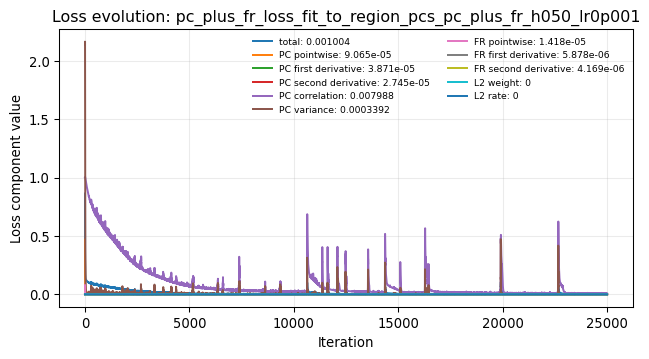

,iteration,loss,reconstruction_loss,mse_loss,temporal_derivative_loss,temporal_curvature_loss,correlation_loss,variance_loss,fr_reconstruction_loss,fr_temporal_derivative_loss,fr_temporal_curvature_loss,rate_loss,weight_loss,l2_rate_loss,l2_weight_loss
24995,24996,0.001143,0.000094,0.000094,0.000039,0.000027,0.008197,0.001487,0.000015,0.000006,0.000004,0.0,0.0,0.0,0.0
24996,24997,0.001135,0.000095,0.000095,0.000040,0.000028,0.008136,0.001438,0.000015,0.000006,0.000004,0.0,0.0,0.0,0.0
24997,24998,0.001129,0.000094,0.000094,0.000039,0.000027,0.008309,0.001229,0.000015,0.000006,0.000004,0.0,0.0,0.0,0.0
24998,24999,0.001052,0.000092,0.000092,0.000039,0.000028,0.008010,0.000768,0.000014,0.000006,0.000004,0.0,0.0,0.0,0.0
24999,25000,0.001004,0.000091,0.000091,0.000039,0.000027,0.007988,0.000339,0.000014,0.000006,0.000004,0.0,0.0,0.0,0.0


In [5]:
def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(7.8, 3.8), dpi=130)
    for column, label in [
        ("loss", "total"),
        ("reconstruction_loss", "PC pointwise"),
        ("temporal_derivative_loss", "PC first derivative"),
        ("temporal_curvature_loss", "PC second derivative"),
        ("correlation_loss", "PC correlation"),
        ("variance_loss", "PC variance"),
        ("fr_reconstruction_loss", "FR pointwise"),
        ("fr_temporal_derivative_loss", "FR first derivative"),
        ("fr_temporal_curvature_loss", "FR second derivative"),
        ("l2_weight_loss", "L2 weight"),
        ("l2_rate_loss", "L2 rate"),
    ]:
        if column in history:
            final_value = float(history[column].iloc[-1])
            ax.plot(history["iteration"], history[column], label=f"{label}: {final_value:.4g}")
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss component value")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=7, ncol=2)
    display_figure(fig)
    return fig, ax


plot_loss(history, f"Loss evolution: {scratch_id}")
display(history.tail())


## 6. PC Reconstruction Quality

This section reports reconstruction metrics in PC space and then overlays the top 3 observed PC trajectories with the mRNN reconstructions. Observed PC trajectories are solid. mRNN reconstructions are dotted in the same fixation-condition color.

,region,condition,mse,mae,r2,correlation
0,ofc,face_interactive,0.000081,0.006925,0.990629,0.995370
1,ofc,face_non_interactive,0.000102,0.007766,0.991928,0.996006
2,ofc,object,0.000113,0.008079,0.993895,0.996949
3,bla,face_interactive,0.000090,0.007113,0.993525,0.996787
4,bla,face_non_interactive,0.000116,0.008226,0.995892,0.997946
5,bla,object,0.000124,0.008633,0.995744,0.997888
6,dmpfc,face_interactive,0.000092,0.007113,0.978292,0.989276
7,dmpfc,face_non_interactive,0.000082,0.006797,0.992826,0.996415
8,dmpfc,object,0.000082,0.006835,0.990757,0.995383
9,accg,face_interactive,0.000061,0.006016,0.975866,0.988470


,region,observed_variance,reconstructed_variance,reconstructed_to_observed_ratio
0,ofc,0.013428,0.013497,1.005191
1,bla,0.024063,0.024178,1.004761
2,dmpfc,0.008286,0.008319,1.003964
3,accg,0.005290,0.005317,1.005239


,region,pc,mse,correlation
0,ofc,1,0.000118,0.999695
1,ofc,2,0.000098,0.999484
2,ofc,3,0.000129,0.998449
3,bla,1,0.000078,0.999890
4,bla,2,0.000098,0.999766
5,bla,3,0.000305,0.996916
6,dmpfc,1,0.000053,0.999804
7,dmpfc,2,0.000042,0.999685
8,dmpfc,3,0.000169,0.996298
9,accg,1,0.000064,0.999577


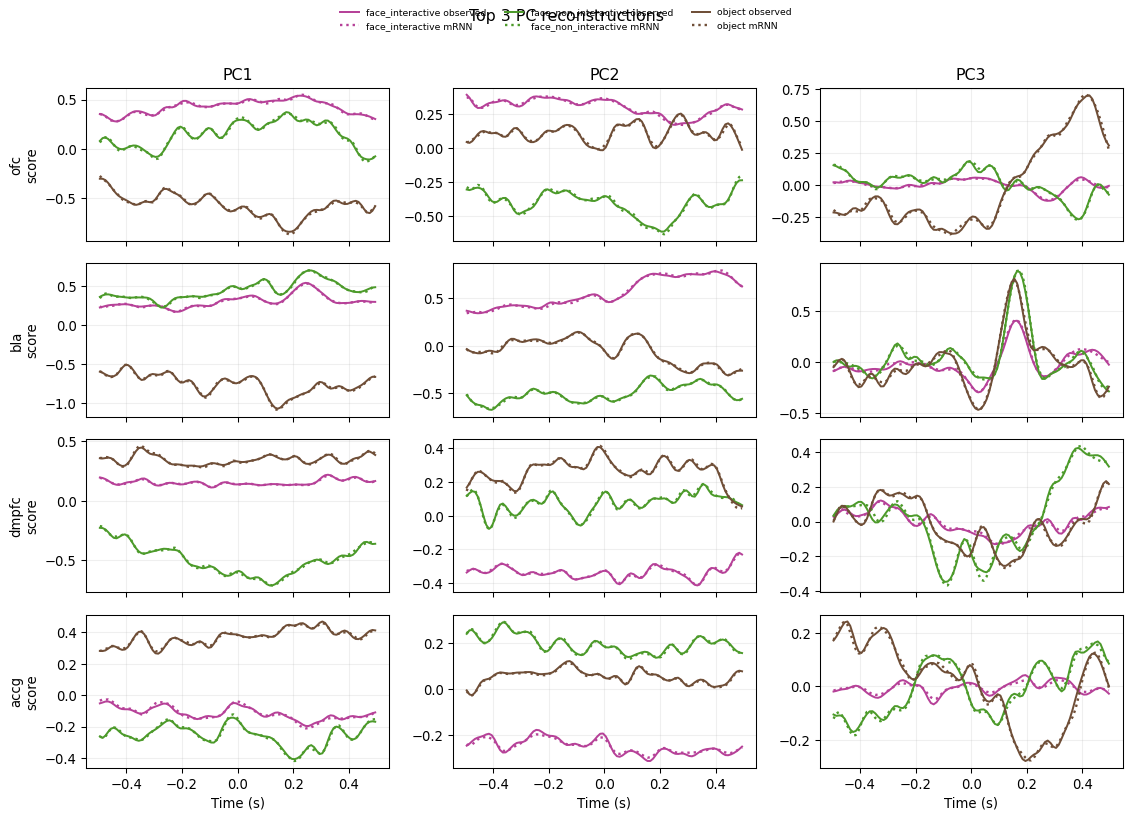

(<Figure size 1560x1092 with 12 Axes>,
 array([[<Axes: title={'center': 'PC1'}, ylabel='ofc\nscore'>,
         <Axes: title={'center': 'PC2'}>, <Axes: title={'center': 'PC3'}>],
        [<Axes: ylabel='bla\nscore'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='dmpfc\nscore'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='Time (s)', ylabel='accg\nscore'>,
         <Axes: xlabel='Time (s)'>, <Axes: xlabel='Time (s)'>]],
       dtype=object))

In [6]:
pc_accuracy = reconstruction_accuracy(replay)
pc_variance = variance_comparison(replay)
display(pc_accuracy)
display(pc_variance)


def top_pc_quality_table(replay, *, n_pcs=3):
    rows = []
    for region in replay["region_order"]:
        observed = np.asarray(replay["checkpoint"]["target_by_region"][region], dtype=float)
        predicted = replay["output_by_region"][region].detach().cpu().numpy().astype(float, copy=False)
        for pc_idx in range(min(int(n_pcs), observed.shape[-1])):
            y = observed[:, :, pc_idx].reshape(-1)
            yhat = predicted[:, :, pc_idx].reshape(-1)
            err = y - yhat
            rows.append({
                "region": region,
                "pc": pc_idx + 1,
                "mse": float(np.mean(err ** 2)),
                "correlation": float(np.corrcoef(y, yhat)[0, 1]) if np.std(y) > 0 and np.std(yhat) > 0 else np.nan,
            })
    return pd.DataFrame(rows)


def plot_pc_reconstructions(replay, *, n_pcs=3):
    conditions = tuple(replay["condition_order"])
    regions = tuple(replay["region_order"])
    time = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    fig, axes = plt.subplots(len(regions), int(n_pcs), figsize=(4.0 * int(n_pcs), 2.1 * len(regions)), dpi=130, sharex=True, squeeze=False)
    for row, region in enumerate(regions):
        observed = np.asarray(replay["checkpoint"]["target_by_region"][region], dtype=float)
        predicted = replay["output_by_region"][region].detach().cpu().numpy()
        for pc_idx in range(int(n_pcs)):
            ax = axes[row, pc_idx]
            for cond_idx, condition in enumerate(conditions):
                color = CONDITION_COLORS.get(condition)
                ax.plot(time, observed[cond_idx, :, pc_idx], color=color, linewidth=1.5, linestyle="-", label=f"{condition} observed")
                ax.plot(time, predicted[cond_idx, :, pc_idx], color=color, linewidth=1.8, linestyle=":", label=f"{condition} mRNN")
            if row == 0:
                ax.set_title(f"PC{pc_idx + 1}")
            if pc_idx == 0:
                ax.set_ylabel(f"{region}\nscore")
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
            ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=7)
    fig.suptitle("Top 3 PC reconstructions", y=1.02)
    fig.tight_layout()
    display_figure(fig)
    return fig, axes


display(top_pc_quality_table(replay, n_pcs=3))
plot_pc_reconstructions(replay, n_pcs=3)


## 7. PC-Backprojected Firing-Rate Reconstruction Quality

This section compares firing-rate trajectories represented by the retained PCs. The target is not the raw observed mean firing rate; it is the observed PC scores back-projected into normalized firing-rate space. Fixation types are split into separate columns for each example unit.

,region,condition,mse,mae,r2,correlation
0,ofc,face_interactive,0.000014,0.002605,0.999847,0.999923
1,ofc,face_non_interactive,0.000018,0.002927,0.999795,0.999898
2,ofc,object,0.000020,0.003064,0.999771,0.999886
3,bla,face_interactive,0.000007,0.001798,0.999908,0.999954
4,bla,face_non_interactive,0.000009,0.002042,0.999876,0.999938
5,bla,object,0.000010,0.002119,0.999878,0.999939
6,dmpfc,face_interactive,0.000021,0.003258,0.999638,0.999819
7,dmpfc,face_non_interactive,0.000018,0.002930,0.999686,0.999843
8,dmpfc,object,0.000018,0.002949,0.999660,0.999830
9,accg,face_interactive,0.000011,0.002371,0.999669,0.999835


,region,unit_idx,unit_label,mse,correlation
0,ofc,0,unit_uuid__1200,1.305772e-05,0.992508
1,ofc,1,unit_uuid__1201,4.601487e-06,0.991680
2,ofc,2,unit_uuid__1202,1.915632e-05,0.995921
3,bla,0,unit_uuid__2500,9.680021e-07,0.995273
4,bla,1,unit_uuid__2501,2.257734e-06,0.996819
5,bla,2,unit_uuid__2502,3.268652e-06,0.995764
6,dmpfc,0,unit_uuid__1700,5.218939e-06,0.991524
7,dmpfc,1,unit_uuid__1701,1.233963e-05,0.976993
8,dmpfc,2,unit_uuid__1702,4.830256e-05,0.993486
9,accg,0,unit_uuid__300,1.958833e-05,0.990587


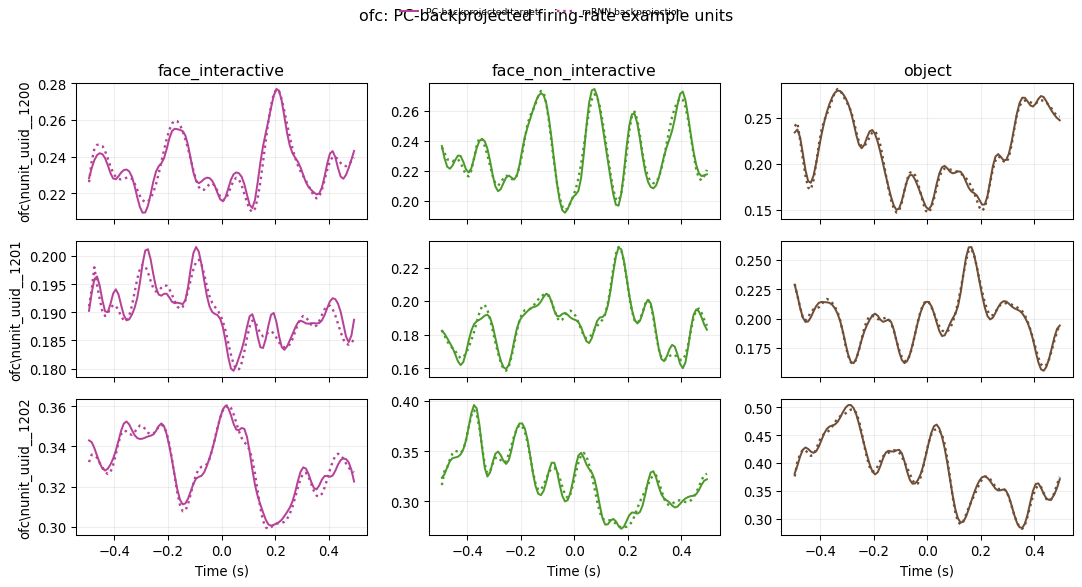

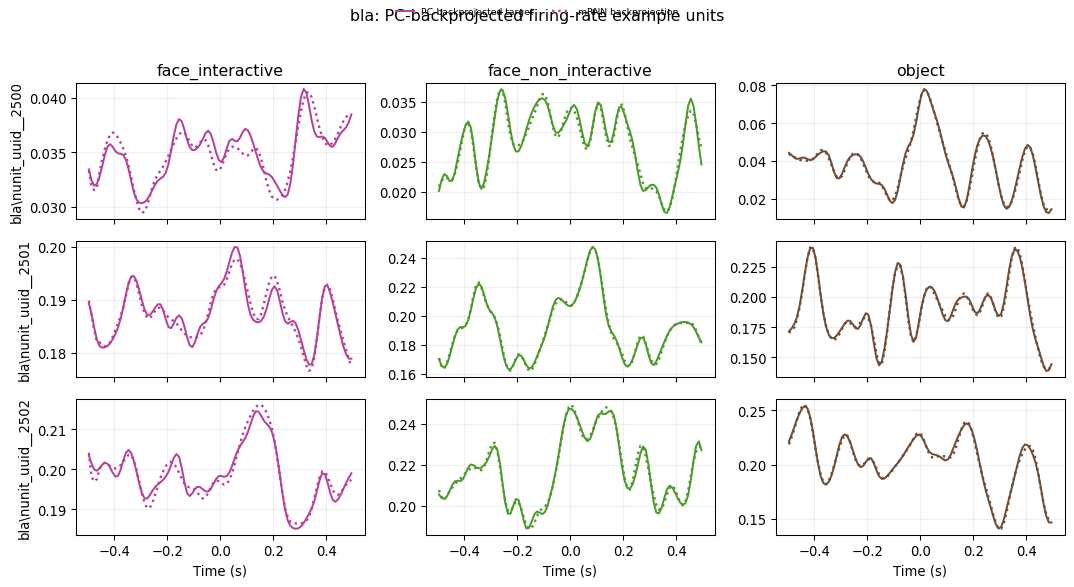

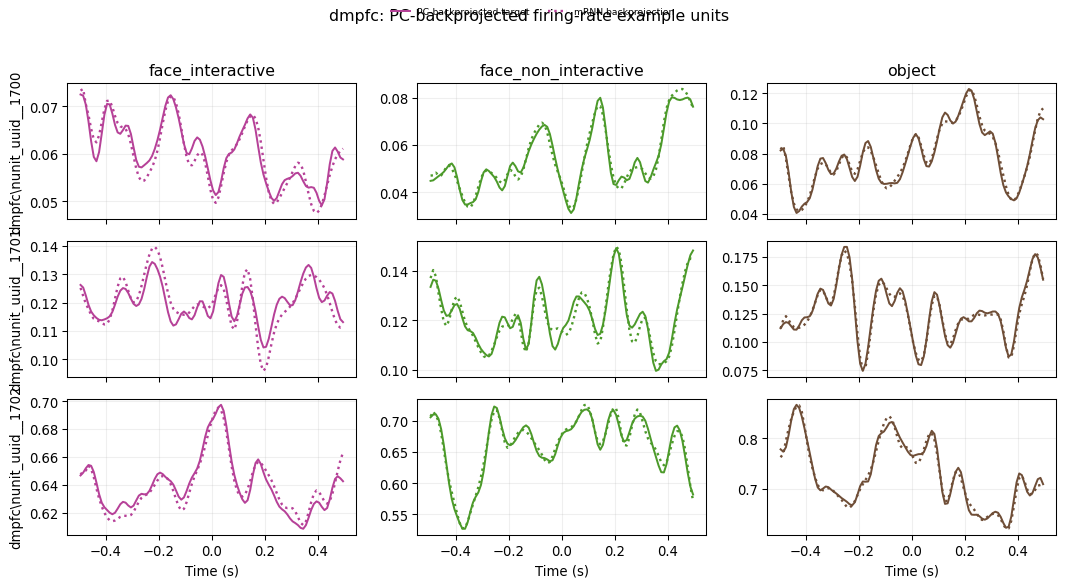

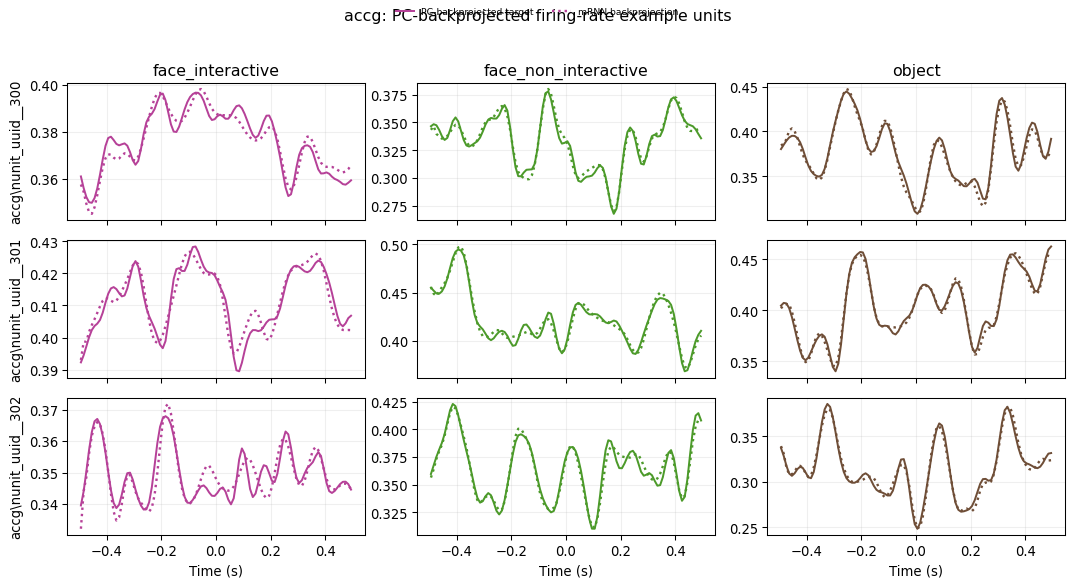

In [7]:
fr_accuracy = pc_reconstructed_firing_rate_accuracy(replay)
display(fr_accuracy)


def example_fr_quality_table(replay, *, example_unit_indices=(0, 1, 2)):
    predicted_fr = backproject_replay_outputs_to_firing_rates(replay)
    target_fr = replay["checkpoint"]["pc_reconstructed_raw_by_region"]
    rows = []
    for region in replay["region_order"]:
        source_features = list(replay["checkpoint"]["pca_by_region"][region]["source_features"])
        available_indices = [idx for idx in example_unit_indices if idx < predicted_fr[region].shape[-1]]
        for unit_idx in available_indices:
            y = np.asarray(target_fr[region][:, :, unit_idx], dtype=float).reshape(-1)
            yhat = np.asarray(predicted_fr[region][:, :, unit_idx], dtype=float).reshape(-1)
            err = y - yhat
            rows.append({
                "region": region,
                "unit_idx": unit_idx,
                "unit_label": source_features[unit_idx] if unit_idx < len(source_features) else f"unit {unit_idx}",
                "mse": float(np.mean(err ** 2)),
                "correlation": float(np.corrcoef(y, yhat)[0, 1]) if np.std(y) > 0 and np.std(yhat) > 0 else np.nan,
            })
    return pd.DataFrame(rows)


def plot_pc_backprojected_fr_examples(replay, *, example_unit_indices=(0, 1, 2)):
    predicted_fr = backproject_replay_outputs_to_firing_rates(replay)
    target_fr = replay["checkpoint"]["pc_reconstructed_raw_by_region"]
    conditions = tuple(replay["condition_order"])
    regions = tuple(replay["region_order"])
    time = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    for region in regions:
        source_features = list(replay["checkpoint"]["pca_by_region"][region]["source_features"])
        available_indices = [idx for idx in example_unit_indices if idx < predicted_fr[region].shape[-1]]
        fig, axes = plt.subplots(
            len(available_indices),
            len(conditions),
            figsize=(3.8 * len(conditions), 2.0 * len(available_indices)),
            dpi=130,
            sharex=True,
            squeeze=False,
        )
        for row, unit_idx in enumerate(available_indices):
            for col, condition in enumerate(conditions):
                cond_idx = conditions.index(condition)
                ax = axes[row, col]
                color = CONDITION_COLORS.get(condition)
                ax.plot(
                    time,
                    target_fr[region][cond_idx, :, unit_idx],
                    color=color,
                    linewidth=1.5,
                    linestyle="-",
                    label="PC-backprojected target",
                )
                ax.plot(
                    time,
                    predicted_fr[region][cond_idx, :, unit_idx],
                    color=color,
                    linewidth=1.8,
                    linestyle=":",
                    label="mRNN backprojection",
                )
                if row == 0:
                    ax.set_title(condition)
                if col == 0:
                    label = source_features[unit_idx] if unit_idx < len(source_features) else f"unit {unit_idx}"
                    ax.set_ylabel(f"{region}\\n{label}")
                if row == len(available_indices) - 1:
                    ax.set_xlabel("Time (s)")
                ax.grid(alpha=0.2)
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=7)
        fig.suptitle(f"{region}: PC-backprojected firing-rate example units", y=1.02)
        fig.tight_layout()
        display_figure(fig)


display(example_fr_quality_table(replay, example_unit_indices=(0, 1, 2)))
plot_pc_backprojected_fr_examples(replay, example_unit_indices=(0, 1, 2))


## 8. Signed Current Influence Over Time

Current extraction uses the effective recurrent matrix after masks/constraints. For each target region and source region, the source current is projected onto the next target-region hidden activity vector. Signed relative contribution is:

$$C_{s\to r}(t)=\frac{p_{s\to r}(t)}{\sum_q |p_{q\to r}(t)|}$$

Positive values indicate alignment with the target-region next activity vector; negative values indicate opposition. The plots below show how self-region and cross-region recurrent currents contribute over time for each fixation type.

,target_region,source_region,condition,mean_signed_projection,mean_signed_relative_contribution
0,accg,accg,face_interactive,0.108433,0.036650
1,accg,accg,face_non_interactive,0.973151,0.313188
2,accg,accg,object,1.966284,0.428257
3,accg,bla,face_interactive,-1.184403,-0.433810
4,accg,bla,face_non_interactive,0.383640,0.081785
5,accg,bla,object,0.139774,0.004920
6,accg,dmpfc,face_interactive,0.288194,0.104350
7,accg,dmpfc,face_non_interactive,0.089361,0.018368
8,accg,dmpfc,object,1.083797,0.232225
9,accg,ofc,face_interactive,-0.962422,-0.292237


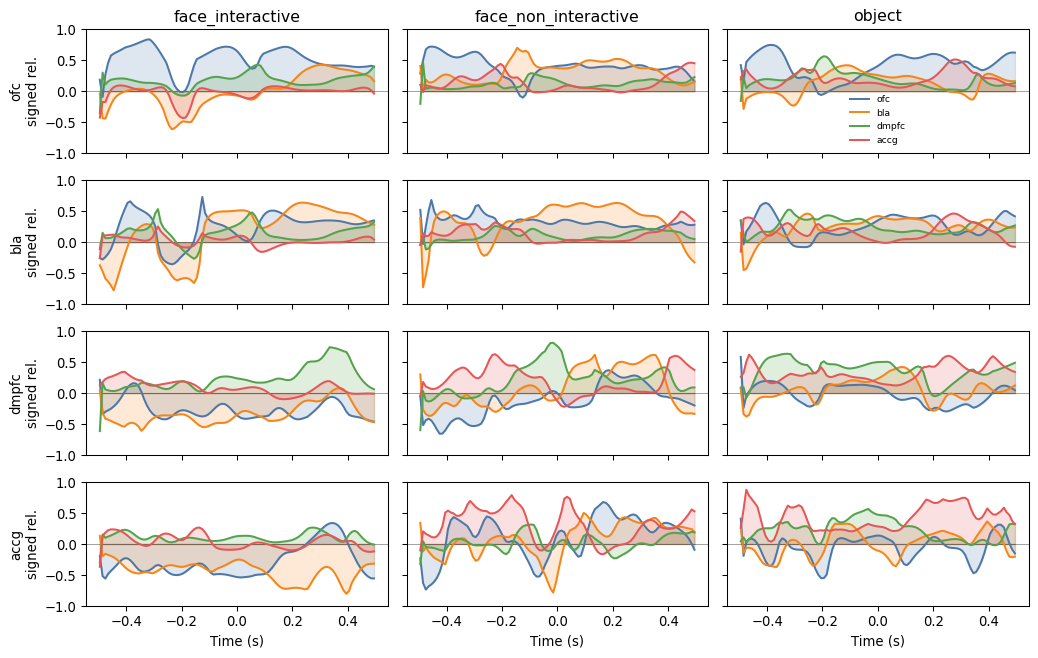

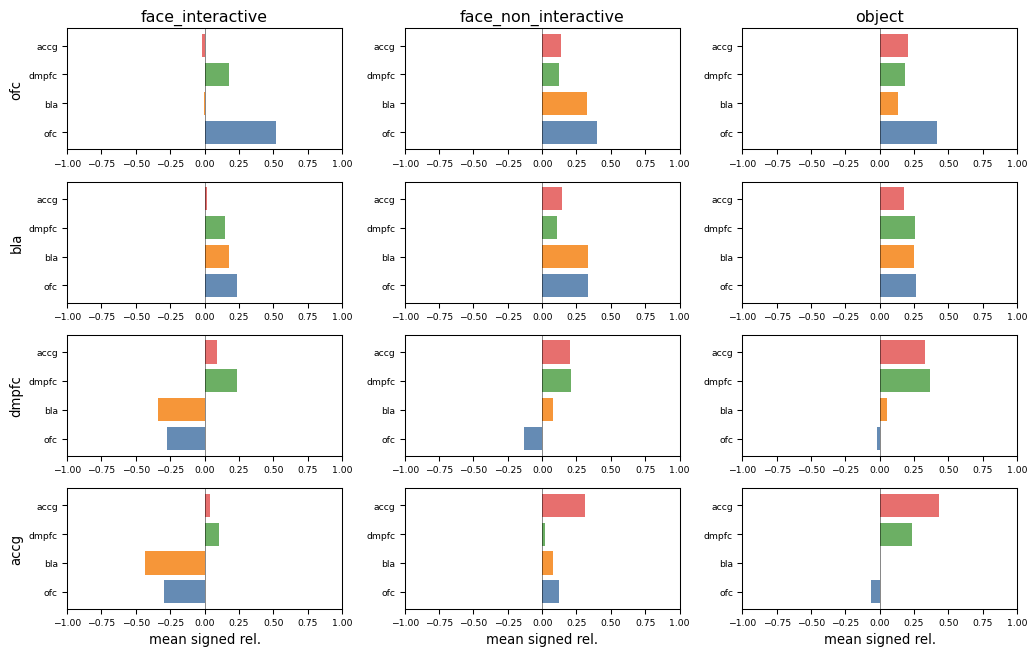

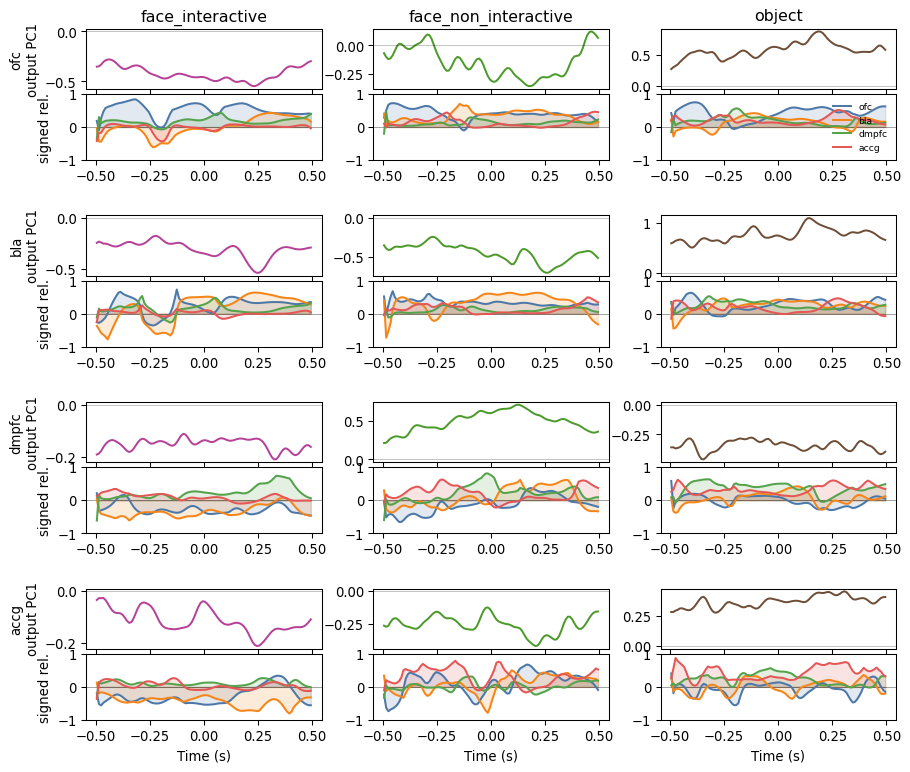

In [8]:
plot_settings = FixationMRNNDiagnosticPlotSettings()
current_df, current_vectors = extract_region_currents(replay)

display(
    current_df.groupby(["target_region", "source_region", "condition"], as_index=False)
    .agg(
        mean_signed_projection=("signed_projection", "mean"),
        mean_signed_relative_contribution=("relative_contribution", "mean"),
    )
)

current_fig, _ = plot_fixation_mrnn_current_influence(replay, settings=plot_settings)
display_figure(current_fig)

bar_fig, _ = plot_fixation_mrnn_average_current_influence_bars(replay, settings=plot_settings)
display_figure(bar_fig)

signal_fig, _ = plot_fixation_mrnn_signal_evolution(replay, settings=plot_settings)
display_figure(signal_fig)
